In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os
print(os.getcwd())

C:\Users\bumba\OneDrive\Desktop\supply-chain-demand-forecasting\notebooks


In [14]:
demand_df = pd.read_csv("../data/raw/daily_demand.csv", parse_dates=["date"])
products_df = pd.read_csv("../data/raw/products.csv")
warehouses_df = pd.read_csv("../data/raw/warehouses.csv")

In [15]:
print(demand_df.shape)
demand_df.head()

(36500, 4)


,date,product_id,warehouse_id,units_sold
0,2024-01-01,1,1,57.0
1,2024-01-02,1,1,67.0
2,2024-01-03,1,1,65.0
3,2024-01-04,1,1,90.0
4,2024-01-05,1,1,62.0


In [16]:
print("Missing values per column:")
print(demand_df.isnull().sum())

print("\nDate range:", demand_df["date"].min(), "to", demand_df["date"].max())

print("\nNegative units_sold rows:", (demand_df["units_sold"] < 0).sum())

print("\nUnique product/warehouse combinations:", 
      demand_df.groupby(["product_id", "warehouse_id"]).ngroups)

Missing values per column:
date            0
product_id      0
warehouse_id    0
units_sold      0
dtype: int64

Date range: 2024-01-01 00:00:00 to 2025-12-30 00:00:00

Negative units_sold rows: 0

Unique product/warehouse combinations: 50


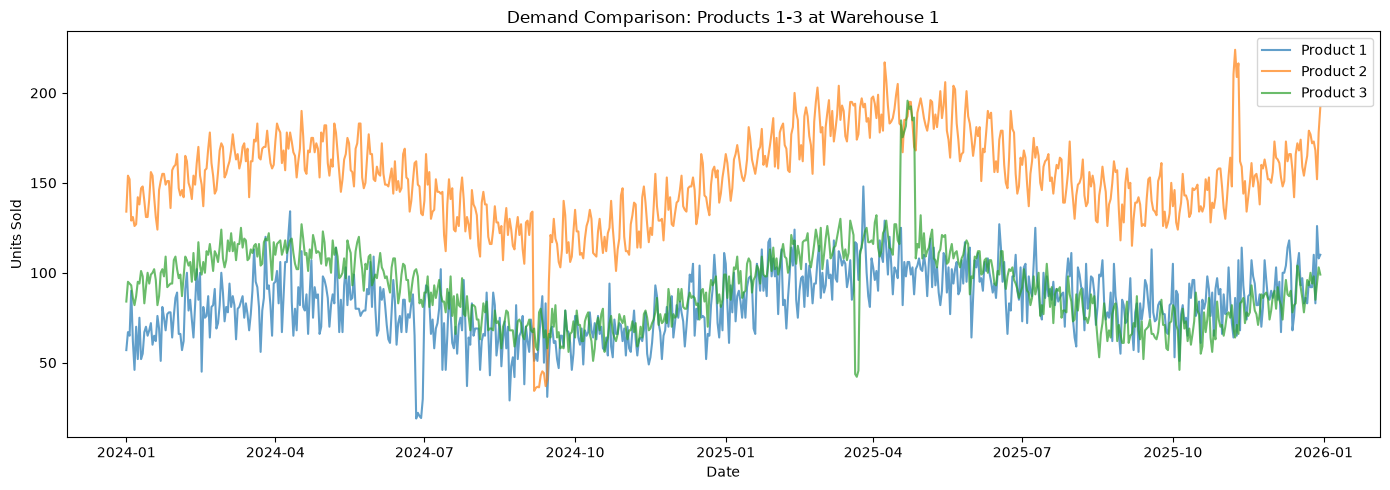

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

for pid in [1, 2, 3]:
    series = demand_df[(demand_df.product_id == pid) & (demand_df.warehouse_id == 1)]
    ax.plot(series["date"], series["units_sold"], label=f"Product {pid}", alpha=0.7)

ax.set_title("Demand Comparison: Products 1-3 at Warehouse 1")
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")
ax.legend()
plt.tight_layout()
plt.savefig("../dashboard/screenshots/demand_comparison.png")
plt.show()

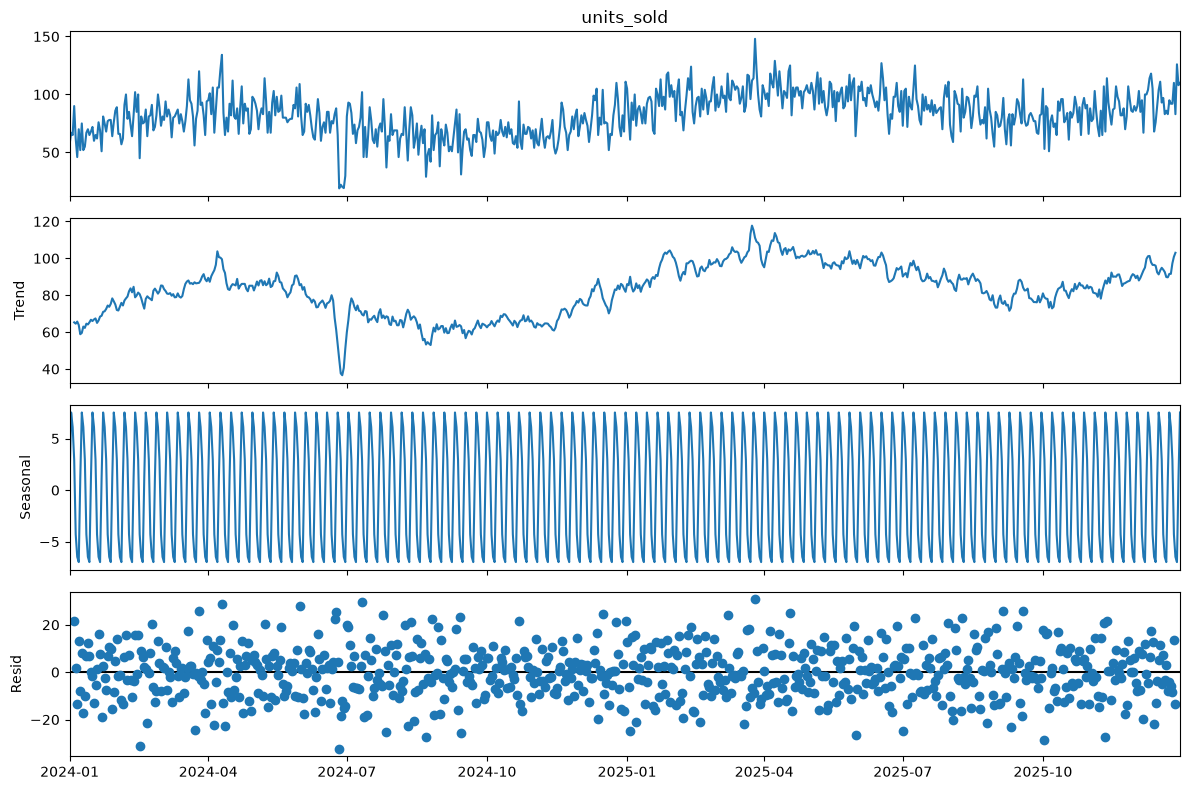

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Focus on one series for a clean decomposition
sample = demand_df[(demand_df.product_id == 1) & (demand_df.warehouse_id == 1)].copy()
sample = sample.set_index("date")["units_sold"]

# period=7 tells it to look for a repeating weekly cycle
decomposition = seasonal_decompose(sample, model="additive", period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig("../dashboard/screenshots/seasonal_decomposition.png")
plt.show()

In [19]:
# Pick one product/warehouse combination to model first
product_id = 1
warehouse_id = 1

series = demand_df[
    (demand_df.product_id == product_id) & (demand_df.warehouse_id == warehouse_id)
][["date", "units_sold"]].copy()

series = series.rename(columns={"date": "ds", "units_sold": "y"})
series = series.sort_values("ds").reset_index(drop=True)

print(series.shape)
series.head()

(730, 2)


,ds,y
0,2024-01-01,57.0
1,2024-01-02,67.0
2,2024-01-03,65.0
3,2024-01-04,90.0
4,2024-01-05,62.0


In [20]:
# Time-based split: train on first ~80%, test on final ~20%
split_point = int(len(series) * 0.8)

train = series.iloc[:split_point]
test = series.iloc[split_point:]

print(f"Train: {train['ds'].min()} to {train['ds'].max()} ({len(train)} days)")
print(f"Test:  {test['ds'].min()} to {test['ds'].max()} ({len(test)} days)")

Train: 2024-01-01 00:00:00 to 2025-08-06 00:00:00 (584 days)
Test:  2025-08-07 00:00:00 to 2025-12-30 00:00:00 (146 days)


In [21]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
model.fit(train)

17:46:58 - cmdstanpy - INFO - Chain [1] start processing
17:46:58 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
# Create a dataframe extending into the future, covering the test period
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

# Extract just the forecasted values for the test period specifically
forecast_test_period = forecast.tail(len(test))

forecast_test_period.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
584,2025-08-07,94.709212,72.066393,103.052778,94.709212,94.709212,-6.951274,-6.951274,-6.951274,3.355409,3.355409,3.355409,-10.306683,-10.306683,-10.306683,0.0,0.0,0.0,87.757938
585,2025-08-08,94.761882,64.154768,94.498896,94.761882,94.761882,-15.135058,-15.135058,-15.135058,-4.382788,-4.382788,-4.382788,-10.752270,-10.752270,-10.752270,0.0,0.0,0.0,79.626824
586,2025-08-09,94.814552,62.796596,94.008785,94.814552,94.814552,-17.581911,-17.581911,-17.581911,-6.399413,-6.399413,-6.399413,-11.182498,-11.182498,-11.182498,0.0,0.0,0.0,77.232641
587,2025-08-10,94.867222,60.624089,90.573517,94.867222,94.867222,-19.135444,-19.135444,-19.135444,-7.540291,-7.540291,-7.540291,-11.595152,-11.595152,-11.595152,0.0,0.0,0.0,75.731779
588,2025-08-11,94.919892,68.482065,99.730086,94.919892,94.919892,-10.877073,-10.877073,-10.877073,1.111391,1.111391,1.111391,-11.988465,-11.988465,-11.988465,0.0,0.0,0.0,84.042819


In [24]:
import os

project_root = os.getcwd()
if os.path.basename(project_root) == "notebooks":
    project_root = os.path.dirname(project_root)

print("Project root:", project_root)

Project root: C:\Users\bumba\OneDrive\Desktop\supply-chain-demand-forecasting


In [25]:
print(demand_df.shape)

(36500, 4)


Saved to: C:\Users\bumba\OneDrive\Desktop\supply-chain-demand-forecasting\dashboard\screenshots\forecast_vs_actual.png


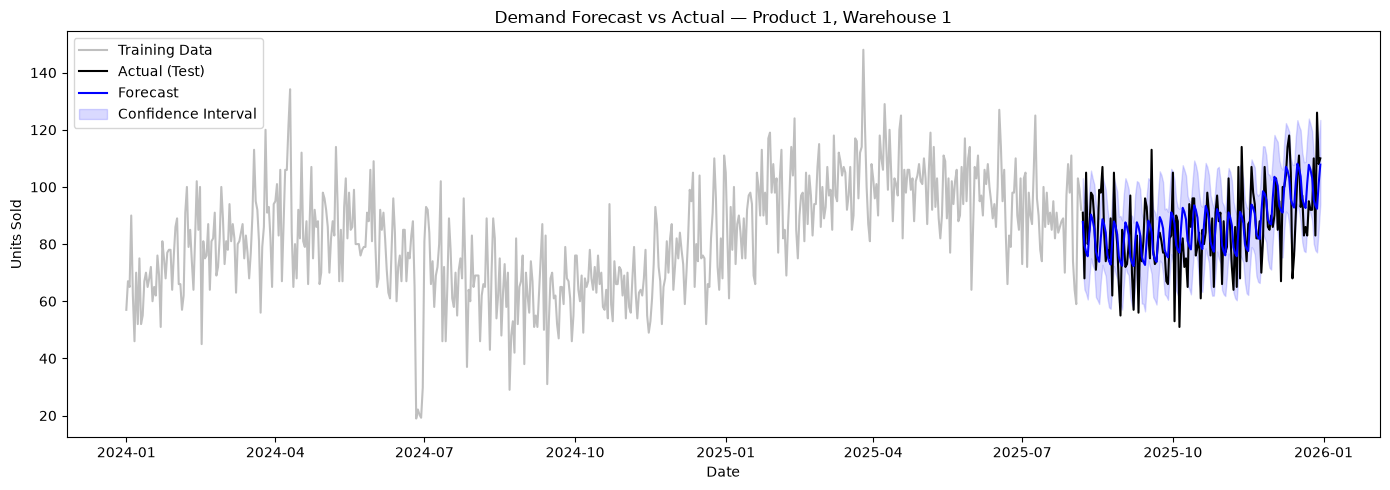

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train["ds"], train["y"], label="Training Data", color="gray", alpha=0.5)
ax.plot(test["ds"], test["y"], label="Actual (Test)", color="black")
ax.plot(forecast_test_period["ds"], forecast_test_period["yhat"], 
        label="Forecast", color="blue")
ax.fill_between(forecast_test_period["ds"], 
                 forecast_test_period["yhat_lower"], 
                 forecast_test_period["yhat_upper"], 
                 color="blue", alpha=0.15, label="Confidence Interval")

ax.set_title(f"Demand Forecast vs Actual — Product {product_id}, Warehouse {warehouse_id}")
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")
ax.legend()
plt.tight_layout()

save_path = os.path.join(project_root, "dashboard", "screenshots", "forecast_vs_actual.png")
plt.savefig(save_path)
print("Saved to:", save_path)
plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

actual = test["y"].values
predicted = forecast_test_period["yhat"].values

mae = mean_absolute_error(actual, predicted)
mape = mean_absolute_percentage_error(actual, predicted) * 100  # convert to percentage

print(f"MAE:  {mae:.2f} units")
print(f"MAPE: {mape:.2f}%")

MAE:  9.81 units
MAPE: 12.14%


In [28]:
def evaluate_product_forecast(demand_df, product_id, warehouse_id, test_frac=0.2):
    series = demand_df[
        (demand_df.product_id == product_id) & (demand_df.warehouse_id == warehouse_id)
    ][["date", "units_sold"]].rename(columns={"date": "ds", "units_sold": "y"}).sort_values("ds").reset_index(drop=True)

    split_point = int(len(series) * (1 - test_frac))
    train = series.iloc[:split_point]
    test = series.iloc[split_point:]

    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, 
                     daily_seasonality=False, changepoint_prior_scale=0.05)
    model.fit(train)

    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)
    forecast_test = forecast.tail(len(test))

    mae = mean_absolute_error(test["y"], forecast_test["yhat"])
    mape = mean_absolute_percentage_error(test["y"], forecast_test["yhat"]) * 100

    return {"product_id": product_id, "warehouse_id": warehouse_id, "mae": mae, "mape": mape}

# Test on a few different series
results = []
for pid, wid in [(1, 1), (5, 3), (8, 2)]:
    result = evaluate_product_forecast(demand_df, pid, wid)
    results.append(result)
    print(result)

17:49:51 - cmdstanpy - INFO - Chain [1] start processing
17:49:51 - cmdstanpy - INFO - Chain [1] done processing
17:49:51 - cmdstanpy - INFO - Chain [1] start processing
17:49:52 - cmdstanpy - INFO - Chain [1] done processing


{'product_id': 1, 'warehouse_id': 1, 'mae': 9.805407421732637, 'mape': 12.14223936695547}


17:49:52 - cmdstanpy - INFO - Chain [1] start processing
17:49:52 - cmdstanpy - INFO - Chain [1] done processing


{'product_id': 5, 'warehouse_id': 3, 'mae': 9.142557092952991, 'mape': 5.695592232535593}
{'product_id': 8, 'warehouse_id': 2, 'mae': 7.535000221240265, 'mape': 11.081868974753284}


In [29]:
results_df = pd.DataFrame(results)
print(results_df)

results_df.to_csv(os.path.join(project_root, "data", "processed", "forecast_evaluation.csv"), index=False)

   product_id  warehouse_id       mae       mape
0           1             1  9.805407  12.142239
1           5             3  9.142557   5.695592
2           8             2  7.535000  11.081869
